In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error
from keras import optimizers
from keras.layers import LSTM
from keras.layers import Dense, Reshape
from keras.models import Sequential
import math
import sys
sys.path.insert(0, '..')
from lstm import AVERT_LSTM

processed_dpath = '../processed_data/'

### Basic usage example

In [ ]:
# usage

# read in dataInterpolated.csv
df = pd.read_csv(processed_dpath+f'dataInterpolated.csv', index_col=0)

# define variables for LSTM
lstm_vars = ['Eruption_Activity', 'VPCC_RSAM', 'VPPC_RSAM', 'VPNC_RSAM', 'VPRS_RSAM', 'VPNC_Intensity', 'CO2_ppm', 'lake_size'] 

# define and fit the model
lstm = AVERT_LSTM(df, lstm_vars=lstm_vars)
lstm.CreateModel(n_past=3, n_future=2, n_epochs=2)
lstm.Fit()

# predict using the model
lstm.Predict()
lstm.PlotData([lstm.df, lstm.df_pred])

# original DataFrame
dataOrig = lstm.df

# predicted DataFrame
dataPred = lstm.df_pred

### Alex sandbox

/Users/oxide/Documents/research/orenstein/code/P288FinalProject/notebooks/../lstm.py:36: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.fillna(0, inplace=True)
/Users/oxide/miniconda3/envs/p188/lib/python3.13/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 400)            │       654,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 120)            │        48,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_4 (Reshape)             │ (None, 15, 8)          │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 702,520 (2.68 MB)

 Trainable params: 702,520 (2.68 MB)

 Non-trainable params: 0 (0.00 B)

Performing Training...
Epoch 1/150
3/3 - 2s - 557ms/step - loss: 0.2063 - val_loss: 0.1949
Epoch 2/150
3/3 - 1s - 195ms/step - loss: 0.1569 - val_loss: 0.1835
Epoch 3/150
3/3 - 1s - 186ms/step - loss: 0.1254 - val_loss: 0.1608
Epoch 4/150
3/3 - 1s - 181ms/step - loss: 0.1237 - val_loss: 0.1522
Epoch 5/150
3/3 - 1s - 189ms/step - loss: 0.1093 - val_loss: 0.1434
Epoch 6/150
3/3 - 1s - 188ms/step - loss: 0.1012 - val_loss: 0.1399
Epoch 7/150
3/3 - 1s - 182ms/step - loss: 0.0970 - val_loss: 0.1364
Epoch 8/150
3/3 - 1s - 181ms/step - loss: 0.0898 - val_loss: 0.1398
Epoch 9/150
3/3 - 1s - 179ms/step - loss: 0.0848 - val_loss: 0.1438
Epoch 10/150
3/3 - 1s - 181ms/step - loss: 0.0789 - val_loss: 0.1320
Epoch 11/150
3/3 - 1s - 187ms/step - loss: 0.0767 - val_loss: 0.1287
Epoch 12/150
3/3 - 1s - 192ms/step - loss: 0.0734 - val_loss: 0.1287
Epoch 13/150
3/3 - 1s - 187ms/step - loss: 0.0710 - val_loss: 0.1275
Epoch 14/150
3/3 - 1s - 187ms/step - loss: 0.0713 - val_loss: 0.1291
Epoch 15/150
3/3 - 1

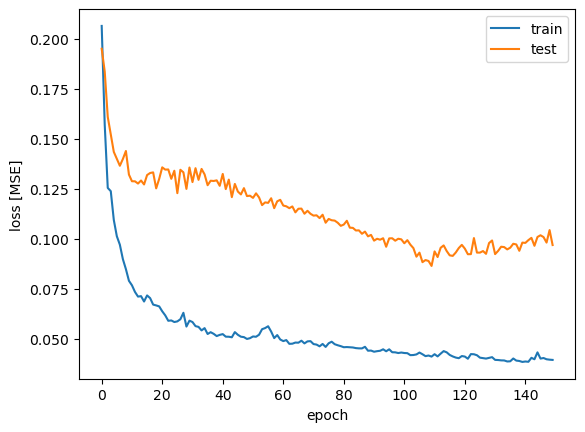

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


/Users/oxide/Documents/research/orenstein/code/P288FinalProject/notebooks/../lstm.py:191: UserWarning: The figure layout has changed to tight
  fig.tight_layout(pad=10)


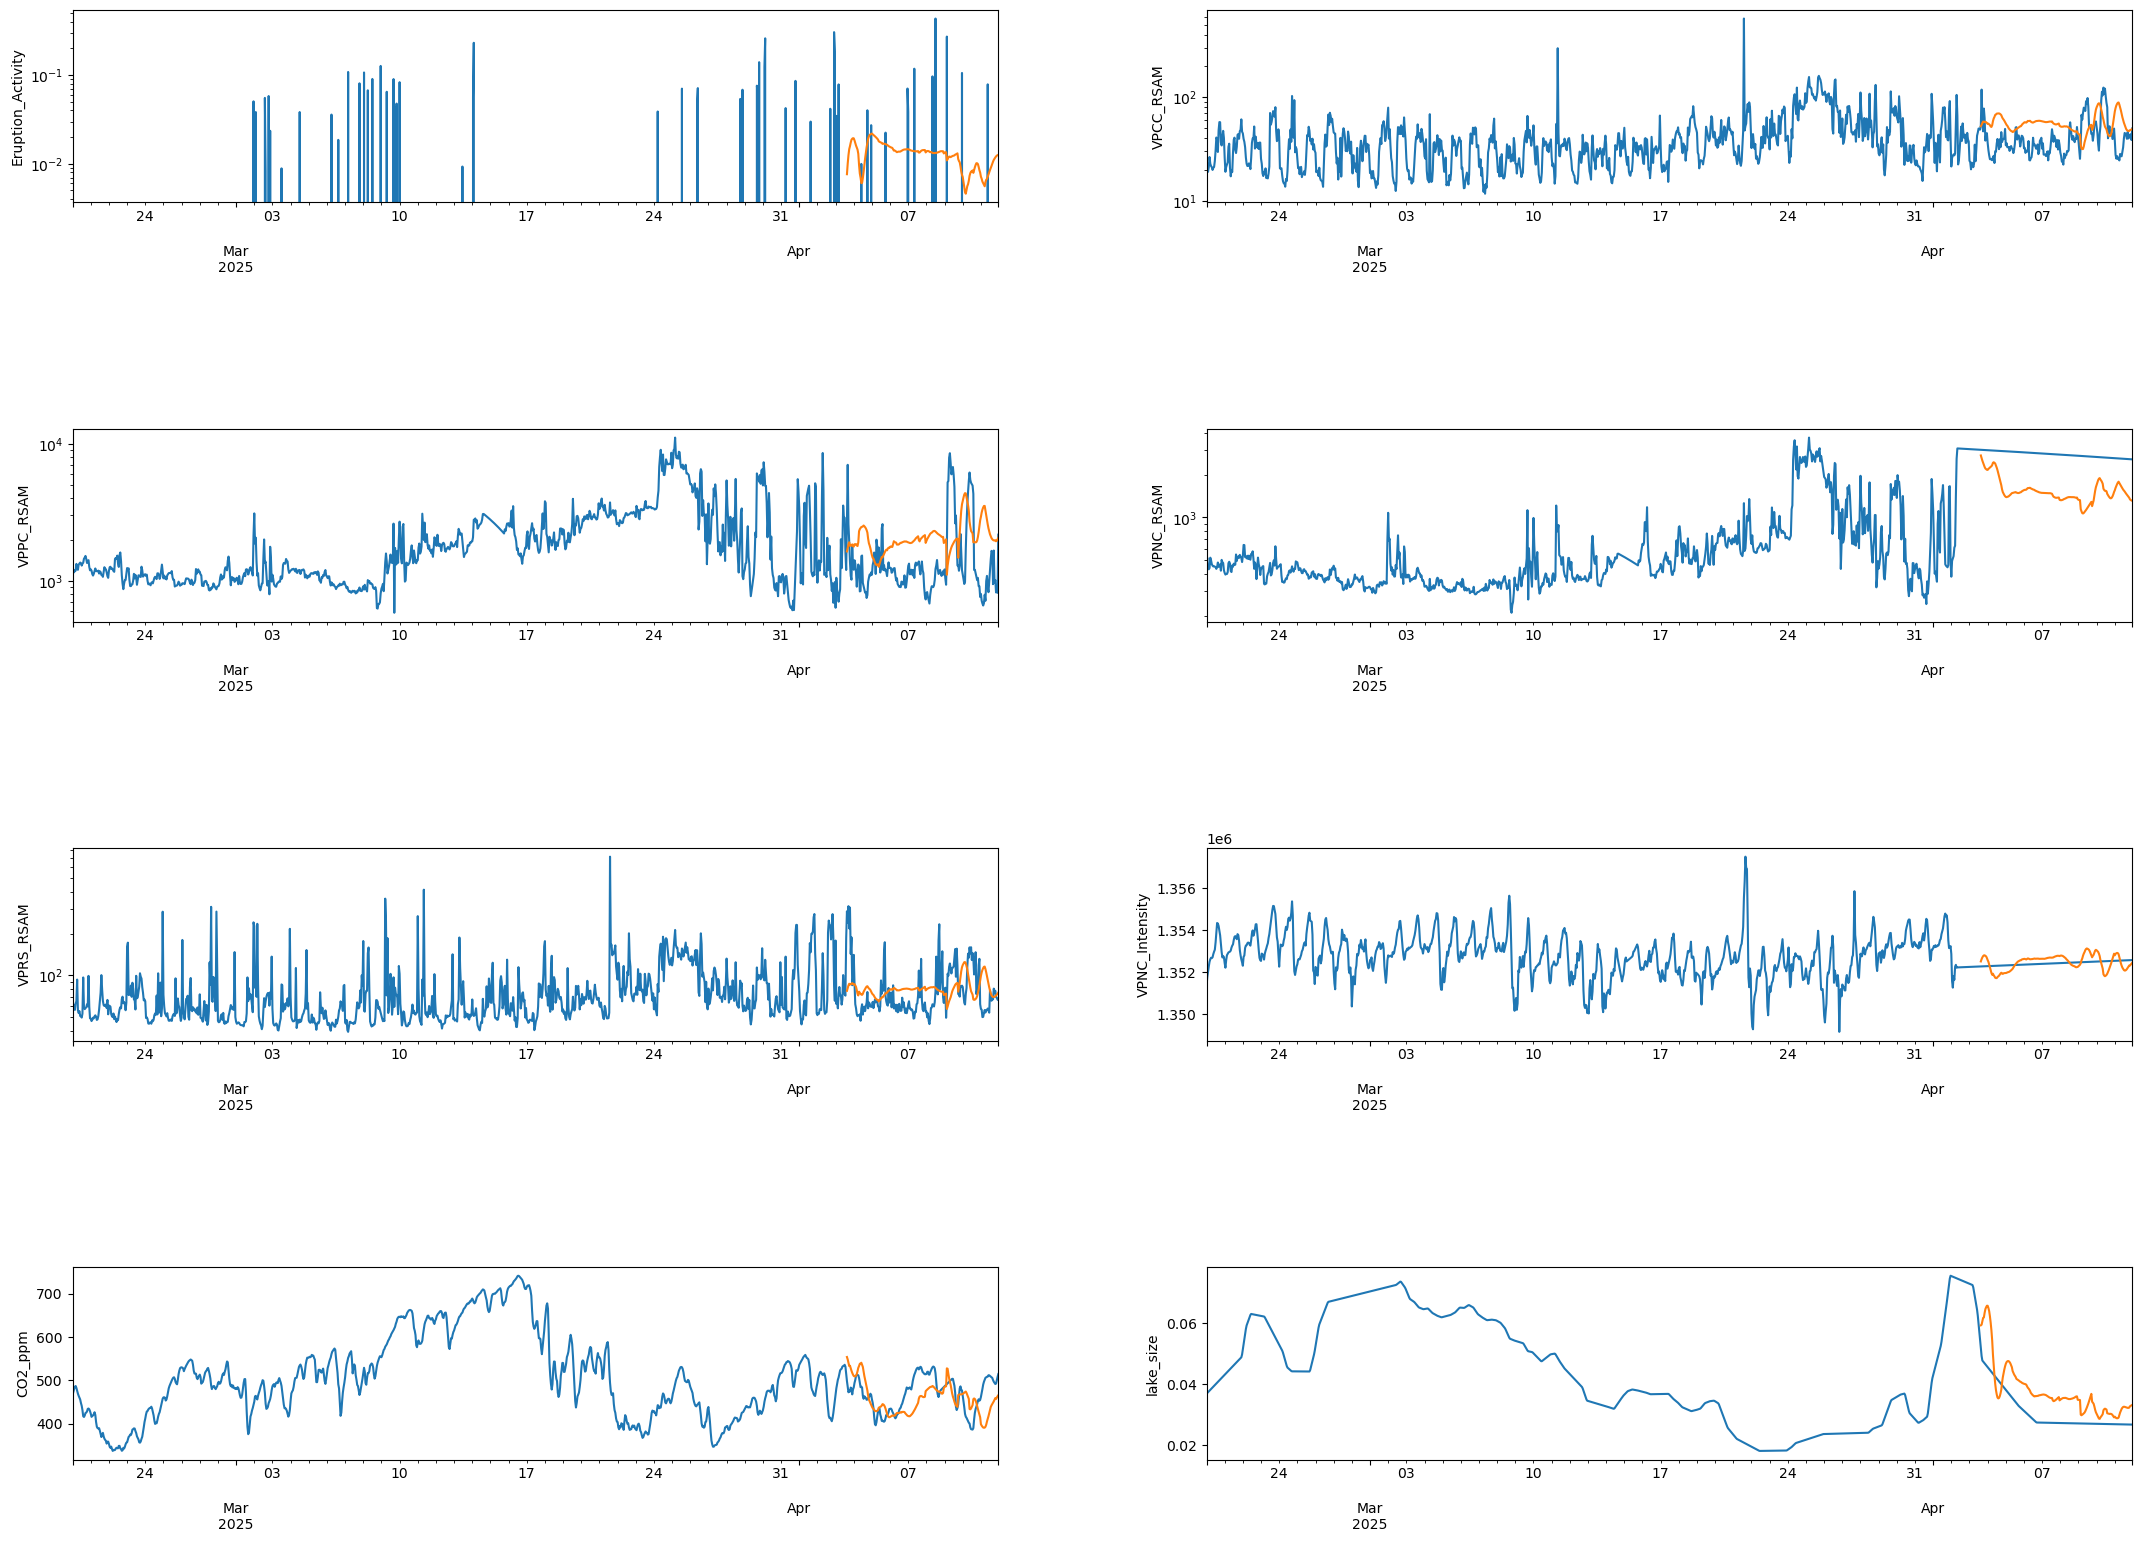

In [8]:
# lets now try to train a model with just a subset of data, say a two month period
#
# for context, the example 1 variable LSTM in LSTMI.ipynb had 643,200+3,208 paramters in it, and the length of the training set was 168 time steps. This ran 150 epochs in a reasonable time. 
#

df = pd.read_csv(processed_dpath+f'dataInterpolated.csv', index_col=0)
df.index = pd.to_datetime(df.index)

# cut the range and resample to one data point per hour
df = df["2025-02-20":"2025-04-11"].resample('h').mean()
lstm_vars = ['Eruption_Activity', 'VPCC_RSAM', 'VPPC_RSAM', 'VPNC_RSAM', 'VPRS_RSAM', 'VPNC_Intensity', 'CO2_ppm', 'lake_size'] 

# define model and plot data
lstm = AVERT_LSTM(df, lstm_vars=lstm_vars)
lstm.CreateModel(n_past=30, n_future=15, n_epochs=150)
#lstm.model.summary()
lstm.Fit()
lstm.Predict()
lstm.PlotData([lstm.df, lstm.df_pred])

/Users/oxide/Documents/research/orenstein/code/P288FinalProject/notebooks/../lstm.py:36: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.fillna(0, inplace=True)
/Users/oxide/miniconda3/envs/p188/lib/python3.13/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_5 (LSTM)                   │ (None, 400)            │       654,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 120)            │        48,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_5 (Reshape)             │ (None, 15, 8)          │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 702,520 (2.68 MB)

 Trainable params: 702,520 (2.68 MB)

 Non-trainable params: 0 (0.00 B)

Performing Training...
Epoch 1/450
3/3 - 2s - 572ms/step - loss: 0.2110 - val_loss: 0.1968
Epoch 2/450
3/3 - 1s - 209ms/step - loss: 0.1557 - val_loss: 0.1852
Epoch 3/450
3/3 - 1s - 205ms/step - loss: 0.1280 - val_loss: 0.1598
Epoch 4/450
3/3 - 1s - 211ms/step - loss: 0.1246 - val_loss: 0.1451
Epoch 5/450
3/3 - 1s - 214ms/step - loss: 0.1113 - val_loss: 0.1449
Epoch 6/450
3/3 - 1s - 211ms/step - loss: 0.1026 - val_loss: 0.1440
Epoch 7/450
3/3 - 1s - 204ms/step - loss: 0.0997 - val_loss: 0.1411
Epoch 8/450
3/3 - 1s - 196ms/step - loss: 0.0938 - val_loss: 0.1391
Epoch 9/450
3/3 - 1s - 188ms/step - loss: 0.0897 - val_loss: 0.1389
Epoch 10/450
3/3 - 1s - 214ms/step - loss: 0.0842 - val_loss: 0.1335
Epoch 11/450
3/3 - 1s - 211ms/step - loss: 0.0800 - val_loss: 0.1299
Epoch 12/450
3/3 - 1s - 213ms/step - loss: 0.0774 - val_loss: 0.1299
Epoch 13/450
3/3 - 1s - 210ms/step - loss: 0.0747 - val_loss: 0.1269
Epoch 14/450
3/3 - 1s - 213ms/step - loss: 0.0722 - val_loss: 0.1339
Epoch 15/450
3/3 - 1

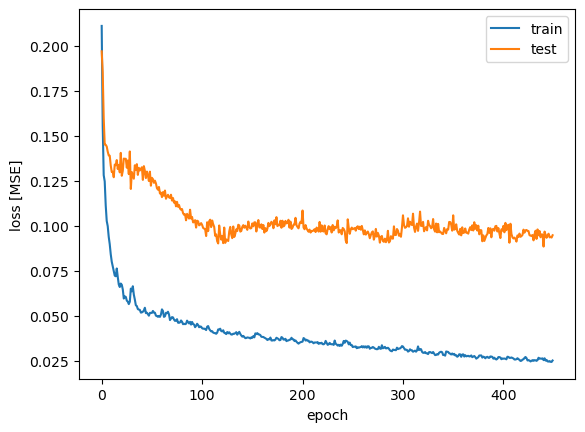

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


/Users/oxide/Documents/research/orenstein/code/P288FinalProject/notebooks/../lstm.py:191: UserWarning: The figure layout has changed to tight
  fig.tight_layout(pad=10)


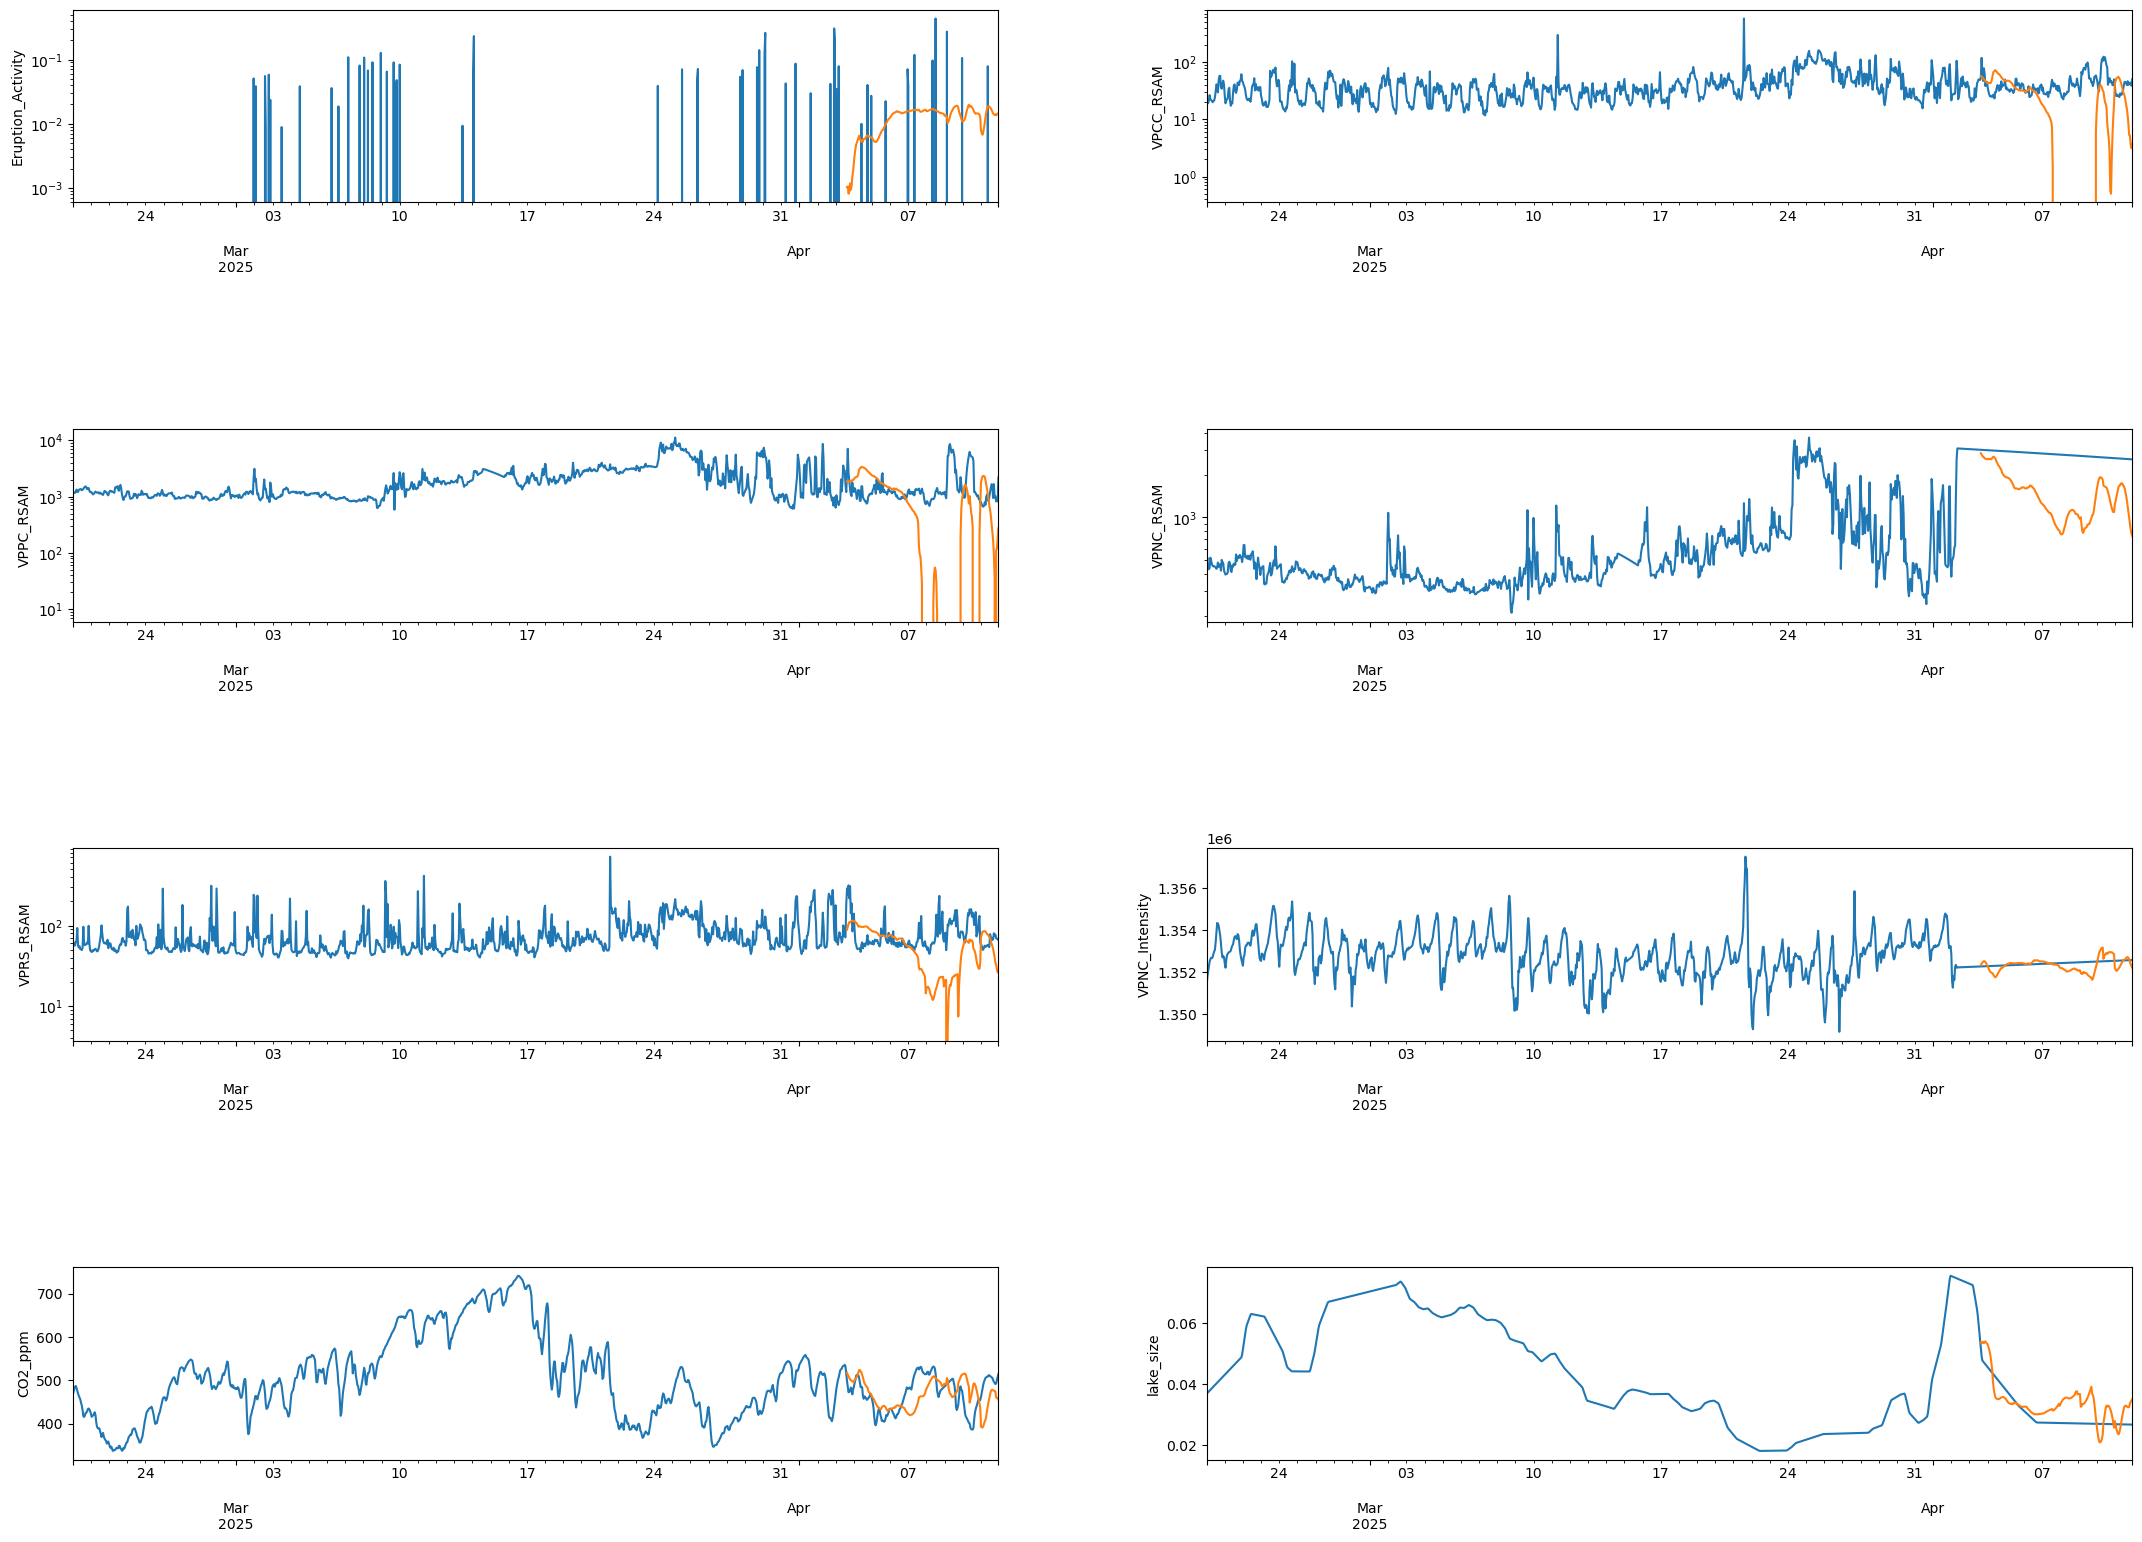

In [9]:
# lets now try to train a model with just a subset of data, say a two month period
#
# for context, the example 1 variable LSTM in LSTMI.ipynb had 643,200+3,208 paramters in it, and the length of the training set was 168 time steps. This ran 150 epochs in a reasonable time. 
#

df = pd.read_csv(processed_dpath+f'dataInterpolated.csv', index_col=0)
df.index = pd.to_datetime(df.index)

# cut the range and resample to one data point per hour
df = df["2025-02-20":"2025-04-11"].resample('h').mean()
lstm_vars = ['Eruption_Activity', 'VPCC_RSAM', 'VPPC_RSAM', 'VPNC_RSAM', 'VPRS_RSAM', 'VPNC_Intensity', 'CO2_ppm', 'lake_size'] 

# define model and plot data
lstm = AVERT_LSTM(df, lstm_vars=lstm_vars)
lstm.CreateModel(n_past=30, n_future=15, n_epochs=450)
#lstm.model.summary()
lstm.Fit()
lstm.Predict()
lstm.PlotData([lstm.df, lstm.df_pred])

In [6]:
lstm.n_divide
lstm.data.shape

(82, 8)

Performing Training...
Epoch 1/350


/Users/oxide/Documents/research/orenstein/code/P288FinalProject/notebooks/../lstm.py:36: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.fillna(0, inplace=True)
/Users/oxide/miniconda3/envs/p188/lib/python3.13/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 - 1s - 1s/step - loss: 0.2868 - val_loss: 0.3451
Epoch 2/350
1/1 - 0s - 111ms/step - loss: 0.2605 - val_loss: 0.3158
Epoch 3/350
1/1 - 0s - 110ms/step - loss: 0.2348 - val_loss: 0.2708
Epoch 4/350
1/1 - 0s - 104ms/step - loss: 0.2052 - val_loss: 0.2361
Epoch 5/350
1/1 - 0s - 99ms/step - loss: 0.1879 - val_loss: 0.2416
Epoch 6/350
1/1 - 0s - 99ms/step - loss: 0.1646 - val_loss: 0.2515
Epoch 7/350
1/1 - 0s - 111ms/step - loss: 0.1612 - val_loss: 0.2575
Epoch 8/350
1/1 - 0s - 115ms/step - loss: 0.1541 - val_loss: 0.2571
Epoch 9/350
1/1 - 0s - 105ms/step - loss: 0.1530 - val_loss: 0.2506
Epoch 10/350
1/1 - 0s - 113ms/step - loss: 0.1516 - val_loss: 0.2482
Epoch 11/350
1/1 - 0s - 107ms/step - loss: 0.1506 - val_loss: 0.2455
Epoch 12/350
1/1 - 0s - 114ms/step - loss: 0.1479 - val_loss: 0.2437
Epoch 13/350
1/1 - 0s - 105ms/step - loss: 0.1458 - val_loss: 0.2422
Epoch 14/350
1/1 - 0s - 106ms/step - loss: 0.1433 - val_loss: 0.2409
Epoch 15/350
1/1 - 0s - 105ms/step - loss: 0.1414 - val_loss

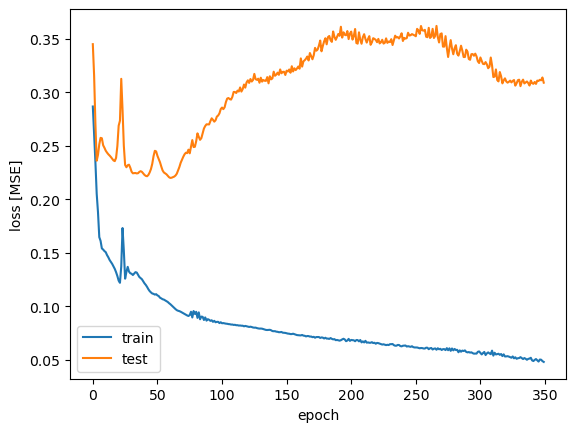

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step


/Users/oxide/Documents/research/orenstein/code/P288FinalProject/notebooks/../lstm.py:192: UserWarning: The figure layout has changed to tight
  fig.tight_layout(pad=10)


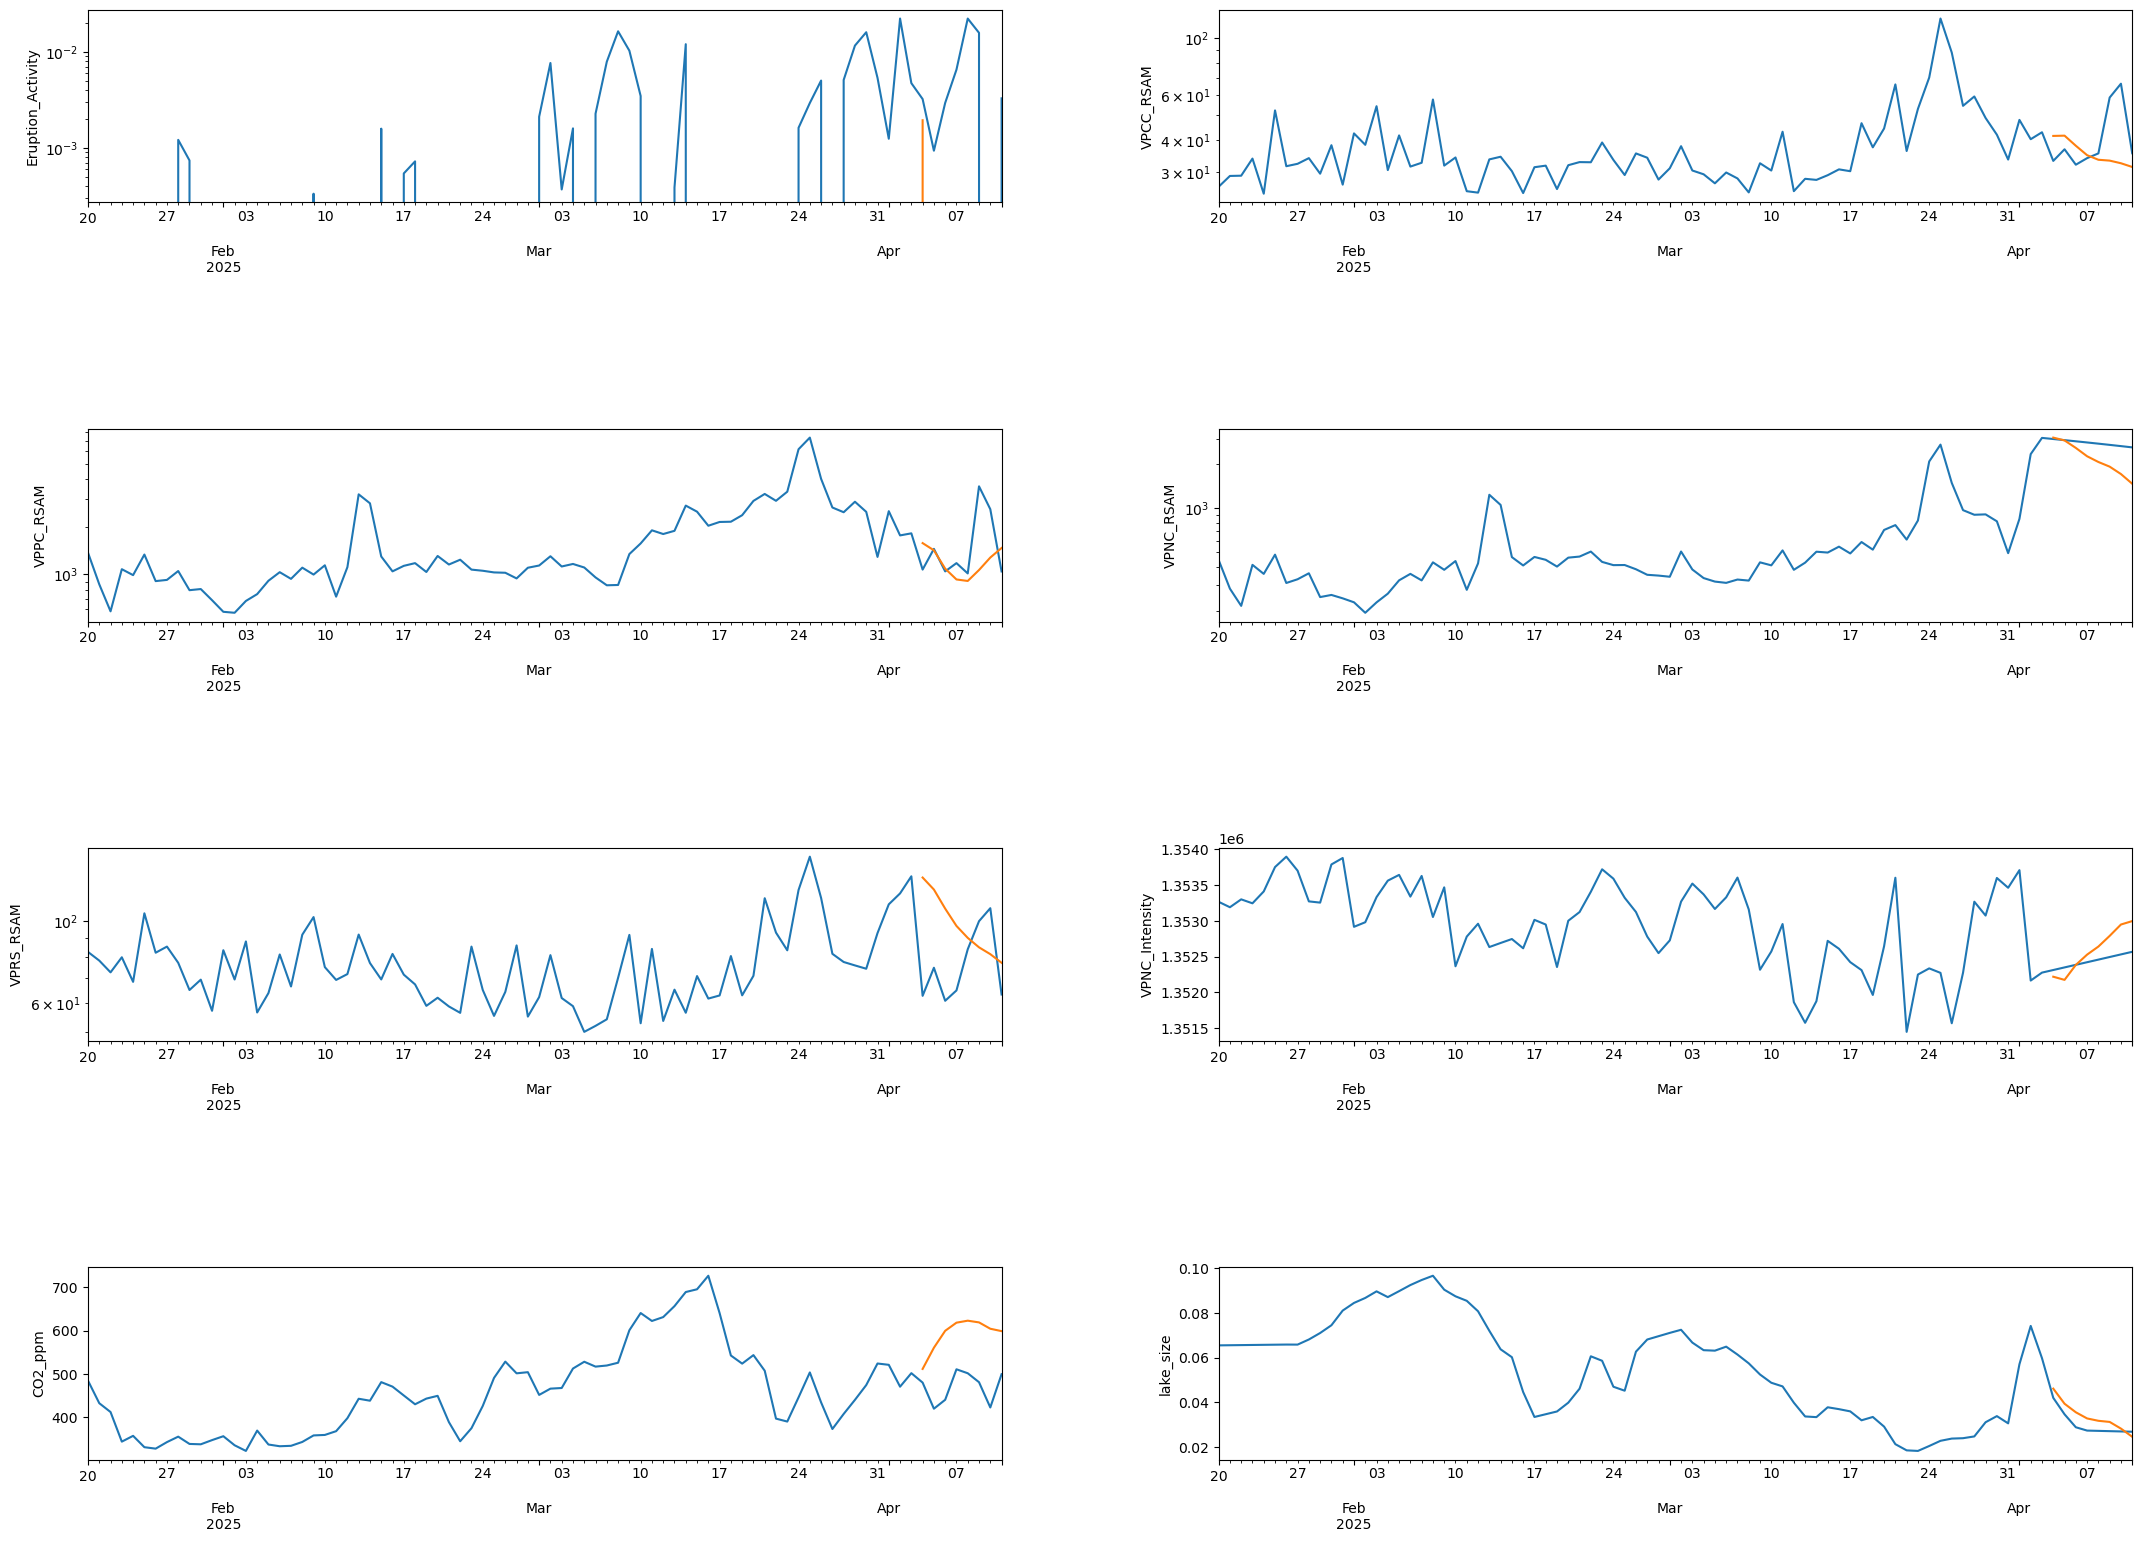

In [3]:
# lets now try to train a model with just a subset of data, say a two month period
#
# for context, the example 1 variable LSTM in LSTMI.ipynb had 643,200+3,208 paramters in it, and the length of the training set was 168 time steps. This ran 150 epochs in a reasonable time. 
#

df = pd.read_csv(processed_dpath+f'dataInterpolated.csv', index_col=0)
df.index = pd.to_datetime(df.index)

# cut the range and resample to one data point per hour
df = df["2025-01-20":"2025-04-11"].
df = df.resample('d').mean()
lstm_vars = ['Eruption_Activity', 'VPCC_RSAM', 'VPPC_RSAM', 'VPNC_RSAM', 'VPRS_RSAM', 'VPNC_Intensity', 'CO2_ppm', 'lake_size'] 

# define model and plot data
lstm = AVERT_LSTM(df, lstm_vars=lstm_vars)
lstm.CreateModel(n_past=30, n_future=15, n_epochs=350, learning_rate=0.001)
#lstm.model.summary()
lstm.Fit()
lstm.Predict()
lstm.PlotData([lstm.df, lstm.df_pred])